In [4]:
%matplotlib inline
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from d2l import torch as d2l

### Exercise 1

Experiment with the value of $\lambda$ in the estimation problem in this section. Plot training and validation accuracy as a function of $\lambda$. What do you observe?

In [5]:
class Data(d2l.DataModule):
    def __init__(self, num_train, num_val, num_inputs, batch_size):
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, num_inputs)
        noise = torch.randn(n, 1) * 0.01
        w, b = torch.ones((num_inputs, 1)) * 0.01, 0.05
        self.y = torch.matmul(self.X, w) + b + noise

    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader([self.X, self.y], train, i)

/Users/zouminghao/Desktop/d2l-notes-exercises/venv/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


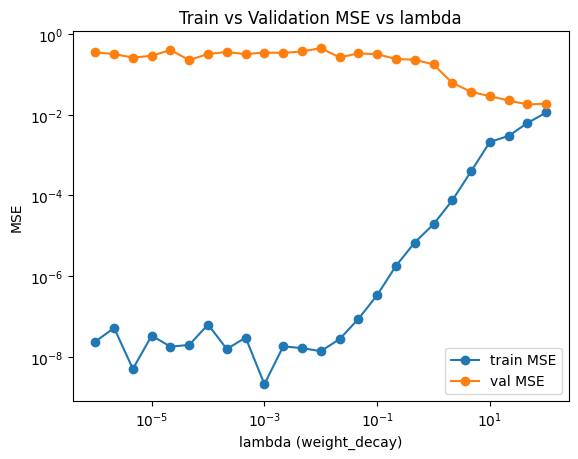

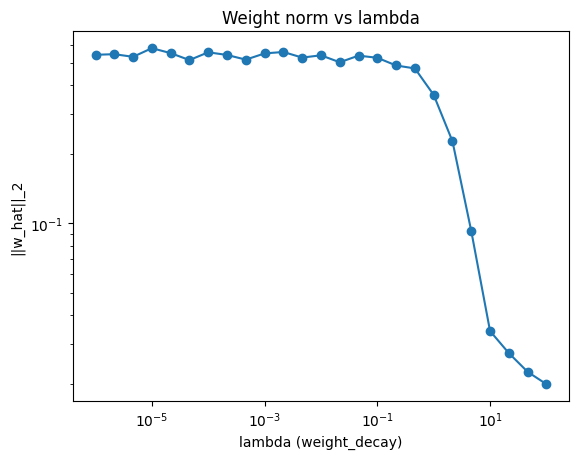

In [6]:
class WeightDecay(d2l.LinearRegression):
    def __init__(self, wd, lr):
        super().__init__(lr)
        self.save_hyperparameters()
        self.wd = wd

    def configure_optimizers(self):
        return torch.optim.SGD([
            {'params': self.net.weight, 'weight_decay': self.wd},
            {'params': self.net.bias}
        ], lr=self.lr)
    def plot(self, key, value, train):
        pass

def eval_mse(model, dataloader):
    """Average MSE over a dataloader."""
    model.eval()
    total_se = 0.0
    total_n = 0
    with torch.no_grad():
        for X, y in dataloader:
            y_hat = model(X)
            total_se += ((y_hat - y) ** 2).sum().item()
            total_n += y.numel()    # number of elements in y
    return total_se / total_n

# Generate data ONCE (your setting)
data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)

# Sweep lambdas
lambdas = np.logspace(-6, 2, 25)  # 25 values from 10^-6 to 10^2

train_curve = []
val_curve = []
wnorm_curve = []

for lam in lambdas:
    model = WeightDecay(wd=float(lam), lr=0.01)
    trainer = d2l.Trainer(max_epochs=10)
    trainer.fit(model, data)

    train_curve.append(eval_mse(model, data.train_dataloader()))
    val_curve.append(eval_mse(model, data.val_dataloader()))

    w_hat, _ = model.get_w_b()
    wnorm_curve.append(torch.norm(w_hat).item())

# Plot train/val MSE vs lambda
plt.figure()
plt.plot(lambdas, train_curve, marker='o', label='train MSE')
plt.plot(lambdas, val_curve, marker='o', label='val MSE')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('lambda (weight_decay)')
plt.ylabel('MSE')
plt.title('Train vs Validation MSE vs lambda')
plt.legend()
plt.show()

# Optional: plot ||w||_2 vs lambda
plt.figure()
plt.plot(lambdas, wnorm_curve, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('lambda (weight_decay)')
plt.ylabel('||w_hat||_2')
plt.title('Weight norm vs lambda')
plt.show()

### Exercise 2

Use a validation set to find the optimal value of $\lambda$. Is it really the optimal value? Does this matter?

The validation-selected $\lambda$ is optimal for this particular validation sample. In expectation, validation error estimates true generalization error. But the $\lambda$ chosen by minimizing validation error can overfit the validation set. With large validation data, this effect becomes negligible.

### Exercise 3

What would the update equations look like if instead of $\|\mathbf{w}\|^2$ we used $\sum_i\left|w_i\right|$ as our penalty of choice ( $\ell_1$ regularization)?

Using the same notation, the update becomes:
$$
\mathbf{w} \leftarrow \mathbf{w}-\eta\left[\frac{1}{|B|} \sum_{i \in B} \mathbf{x}^{(i)}\left(\mathbf{w}^{\top} \mathbf{x}^{(i)}+b-y^{(i)}\right)+\lambda \operatorname{sign}(\mathbf{w})\right] .
$$
Equivalently,
$$
\mathbf{w} \leftarrow \mathbf{w}-\frac{\eta}{|B|} \sum_{i \in B} \mathbf{x}^{(i)}\left(\mathbf{w}^{\top} \mathbf{x}^{(i)}+b-y^{(i)}\right)-\eta \lambda \operatorname{sign}(\mathbf{w})
$$

### Exercise 4

We know that $\|\mathbf{w}\|^2=\mathbf{w}^{\top} \mathbf{w}$. Can you find a similar equation for matrices

For a matrix $A \in \mathbb{R}^{m \times n}$,
$$
\sum_{i, j} A_{i j}^2
$$
can be written as:
$$
\sum_{i, j} A_{i j}^2=\operatorname{tr}\left(A^{\top} A\right)
$$
This is the exact analogue of $w^{\top} w$.

Let's compute $\boldsymbol{A}^{\top} \boldsymbol{A}$.
- $\boldsymbol{A}^{\top} \boldsymbol{A}$ is an $n \times n$ matrix.
- Its $(k, k)$-th diagonal entry is:

$$
\left(\boldsymbol{A}^{\top} \boldsymbol{A}\right)_{k k}=\sum_i \boldsymbol{A}_{i k}^2
$$


Now take the trace:

$$
\operatorname{tr}\left(A^{\top} A\right)=\sum_k\left(A^{\top} A\right)_{k k}=\sum_k \sum_i A_{i k}^2=\sum_{i, j} A_{i j}^2
$$


Exactly what we wanted.

### Exercise 5

Review the relationship between training error and generalization error. In addition to weight decay, increased training, and the use of a model of suitable complexity, what other ways might help us deal with overfitting?

Train multiple models and average predictions.

### Exercise 6

In Bayesian statistics we use the product of prior and likelihood to arrive at a posterior via $P(w \mid x) \propto P(x \mid w) P(w)$. How can you identify $P(w)$ with regularization?

Bayes' rule:
$$
P(w \mid x) \propto P(x \mid w) P(w)
$$
If we want a single estimate of $w$, we often take the MAP estimator:
$$
\hat{w}_{\mathrm{MAP}}=\arg \max _w P(w \mid x)
$$
Since proportional constants don't matter:
$$
\hat{w}=\arg \max _w P(x \mid w) P(w)
$$
Take logs (because logs turn products into sums):
$$
\hat{w}=\arg \max _w[\log P(x \mid w)+\log P(w)]
$$
In regularized regression, we solve:
$$
\hat{w}=\arg \min _w[\operatorname{Loss}(w)+\lambda \cdot \operatorname{Penalty}(w)]
$$
Now compare the two forms:

Bayesian MAP:
$$
\max _w[\log \text { Likelihood }+\log \text { Prior }]
$$
Regularization:
$$
\min _w[\text { Data loss }+\lambda \cdot \text { Penalty }]
$$
If we define:
$$
\text { Data loss }=-\log P(x \mid w)
$$
then:
$$
\operatorname{Penalty}(w)=-\log P(w)
$$
So:
$$
\text { Regularization term }=-\log \text { Prior }
$$
That's the key insight.

Suppose:
$$
P(w)=\mathcal{N}\left(0, \sigma^2 I\right)
$$
Then:
$$
P(w) \propto \exp \left(-\frac{1}{2 \sigma^2}\|w\|^2\right)
$$
Take log:
$$
\log P(w)=-\frac{1}{2 \sigma^2}\|w\|^2+C
$$
Negate it:
$$
-\log P(w)=\frac{1}{2 \sigma^2}\|w\|^2
$$
That is exactly L2 regularization.

So:
$$
\text { L2 regularization ⟺ Gaussian prior on } w
$$
And:
$$
\lambda=\frac{1}{2 \sigma^2}
$$
Suppose:
$$
P\left(w_j\right) \propto \exp \left(-\lambda\left|w_j\right|\right)
$$
This is a Laplace distribution.

Then:
$$
-\log P(w)=\lambda \sum_j\left|w_j\right|
$$
That is L1 regularization.

So:
$$
\text { L1 regularization } \text { ⟺ Laplace prior }
$$
Regularization is not just a computational trick. It is equivalent to saying: Before seeing data, I believe weights are probably small.